In [5]:
import numpy as np
import pyvista as pv

from mpi4py import MPI
from basix.ufl import element
from dolfinx import mesh, fem
from ufl import inner, grad, sqrt, TrialFunction, TestFunction, CellDiameter, dx
from dolfinx.fem.petsc import LinearProblem

from dolfinx import *

In [ ]:
# Mesh and function space
y_lim = 25.0
x_lim = 25.0

domain = mesh.create_rectangle(MPI.COMM_WORLD, ((0,0),(x_lim, y_lim)), [128, 128])
V = fem.functionspace(domain, element("CG", domain.basix_cell(), 1))

# Boundary condition (zero dirichlet)
def boundary(x):
    return np.isclose(x[0], 0.0) | np.isclose(x[1], 0.0)
    
u_zero = fem.Constant(domain, 0.0)
bc_zero = fem.dirichletbc(u_zero, fem.locate_dofs_geometrical(V, boundary), V)

# Velocity field
def velocity_field(x):
    return np.vstack((0.5 * np.ones_like(x[0]), 0.5 * np.ones_like(x[0])))

V_vec = fem.functionspace(domain, ("CG", 1, (domain.geometry.dim,)))
beta = fem.Function(V_vec)
beta.interpolate(velocity_field)

x0, y0 = 0.2 * x_lim, 0.4 * y_lim
sigma_x, sigma_y = 0.02 * y_lim, 0.02 * y_lim

# Source term as 2D-Gauss
def source_term(x: np.ndarray):
    return 10.0 * np.exp(-((x[0] - x0)**2 / (2 * sigma_x**2) + (x[1] - y0)**2 / (2 * sigma_y**2)))

f = fem.Function(V)
f.interpolate(source_term)

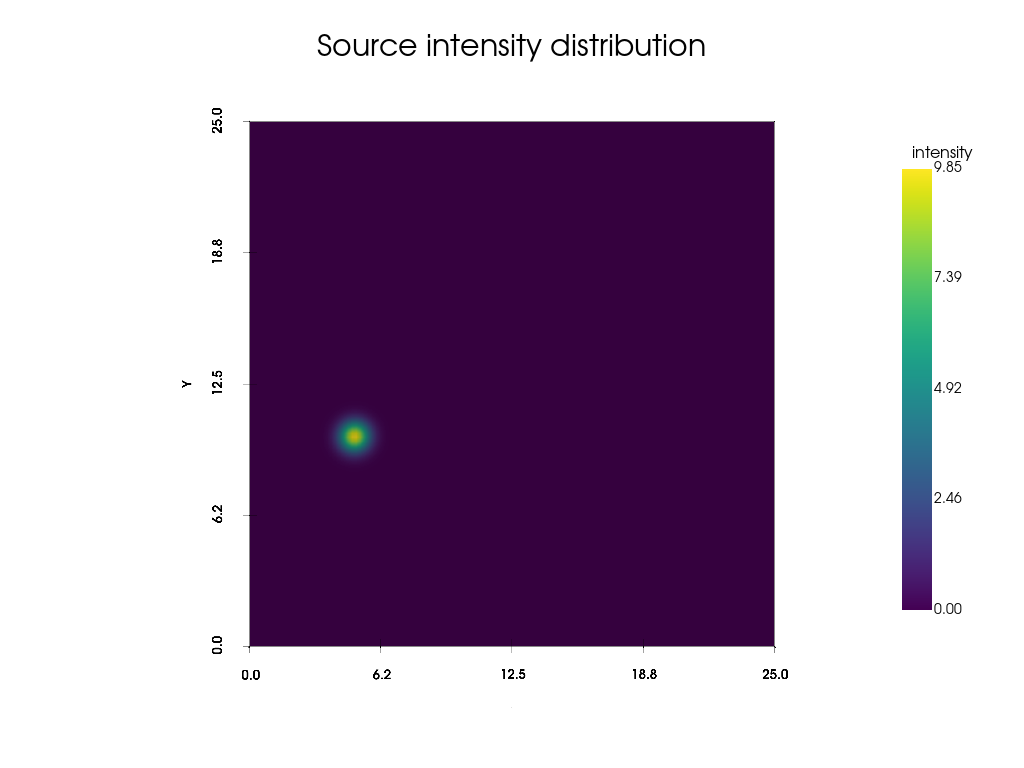

In [ ]:
# Visualize source distribution
x_coords = domain.geometry.x[:, 0]
y_coords = domain.geometry.x[:, 1]
f_values = f.x.array

topology, cell_type, geom = plot.vtk_mesh(domain) 
grid = pv.UnstructuredGrid(topology, cell_type, geom)

grid.point_data["intensity"] = f.x.array  # skalares Feld
plotter = pv.Plotter()
plotter.add_mesh(
    grid, 
    scalars="intensity", 
    cmap="viridis", 
    show_edges=False,
    scalar_bar_args={
        "vertical": True,
        # Adjust the position to shift the colorbar away from the plot
        "position_x": 0.88,
        "position_y": 0.2,
        "height": 0.6,
        "width": 0.08,
        "title_font_size": 16,
        "label_font_size": 14    }
)
plotter.add_title("Source intensity distribution", font_size=12)
plotter.show_grid(xtitle="X", ytitle="Y", font_size=10, grid=False, all_edges=True)
plotter.view_xy()
plotter.show()

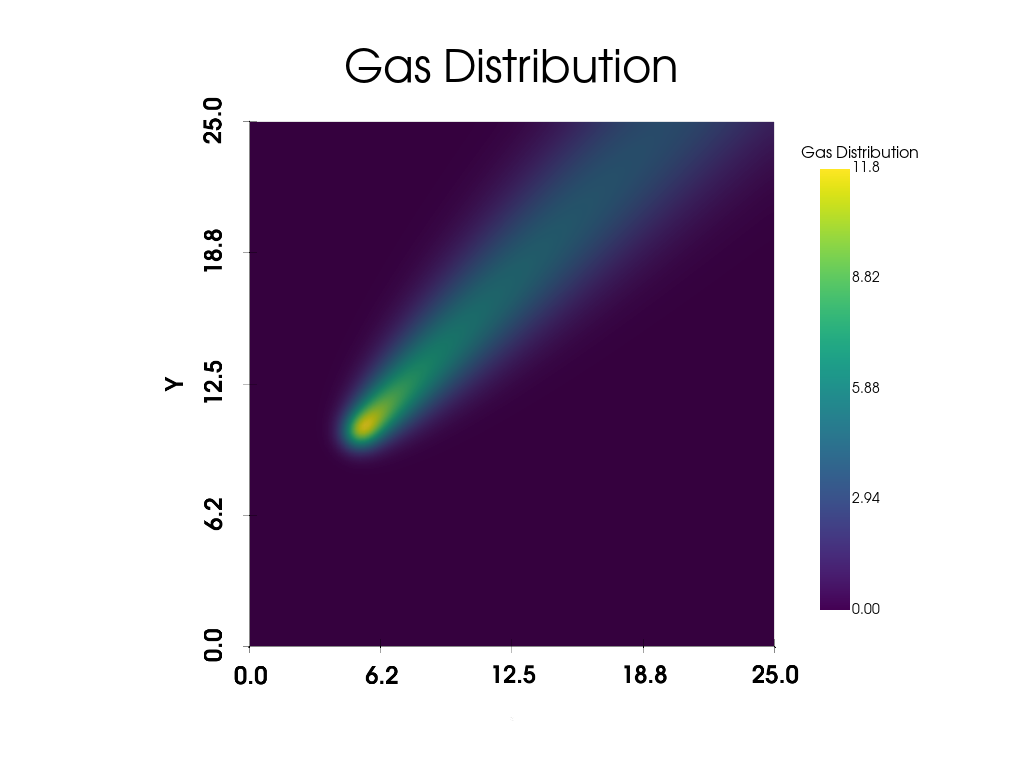

In [ ]:
D_phys = fem.Constant(domain, 0.1)

# Compute Peclet number
U_char = sqrt(inner(beta, beta))
L_char = fem.Constant(domain, x_lim)
h = CellDiameter(domain)
Pe = U_char * L_char / D_phys

v = TestFunction(V)
u = TrialFunction(V)

# a = D_phys * inner(grad(u), grad(v)) * dx + inner(beta, grad(u)) * v * dx
# L = f * v * dx

# SUPG
tau = 0.5 * h * pow(4.0 / (Pe*h) + 2.0 * sqrt(inner(beta, beta)), -1.0)

a_stab = D_phys * inner(grad(u), grad(v)) * dx + inner(beta, grad(u)) * v * dx + \
         tau * inner(beta, grad(u)) * inner(beta, grad(v)) * dx
L_stab = f * v * dx + tau * f * inner(beta, grad(v)) * dx

forward_problem = LinearProblem(a_stab, L_stab, [bc_zero])
uh = forward_problem.solve()

grid.point_data["Gas Distribution"] = uh.x.array

plotter = pv.Plotter()
plotter.add_title("Gas Distribution")
plotter.add_mesh(
    grid, 
    scalars="Gas Distribution", 
    cmap="viridis", 
    show_edges=False,
    scalar_bar_args={
        "vertical": True,
        # Adjust the position to shift the colorbar away from the plot
        "position_x": 0.8,
        "position_y": 0.2,
        "height": 0.6,
        "width": 0.08,
        "title_font_size": 16,
        "label_font_size": 14    }
)
plotter.show_grid(xtitle="X", ytitle="Y", grid=False)
plotter.view_xy()
plotter.show()
